In [ ]:
!git clone https://github.com/RosaCortes/ISY503-Assessment3-NLP.git

Cloning into 'ISY503-Assessment3-NLP'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 101 (delta 35), reused 10 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 30.86 MiB | 10.08 MiB/s, done.
Resolving deltas: 100% (35/35), done.


In [ ]:
import os
import glob
import numpy as np

# Path to processed folder
processed_path = "ISY503-Assessment3-NLP/data/processed"

# Find all .npy files
npy_files = glob.glob(os.path.join(processed_path, "*.npy"))

# Dictionary to store loaded arrays
data = {}

# Loop through and load
for file in npy_files:
    filename = os.path.basename(file).replace(".npy", "")

    data[filename] = np.load(file, allow_pickle=True)

    print(f"Loaded {filename}: shape = {data[filename].shape}")

# Example access
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
X_val = data["X_val"]
y_val = data["y_val"]

Loaded y_train: shape = (1334,)
Loaded X_test: shape = (287, 200)
Loaded X_train: shape = (1334, 200)
Loaded y_val: shape = (286,)
Loaded X_val: shape = (286, 200)
Loaded y_test: shape = (287,)


In [ ]:
import pickle

with open("ISY503-Assessment3-NLP/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [ ]:
# getting the vocabulary size from the tokenizer
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)

Vocabulary size: 19251


In [ ]:
#Model 1 — Simple Dense Network (Strong Baseline)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),

    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# =========================
# EVALUATE
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5117 - loss: 0.6930 - val_accuracy: 0.5393 - val_loss: 0.6916
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5408 - loss: 0.6895 - val_accuracy: 0.4719 - val_loss: 0.6937
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5473 - loss: 0.6876 - val_accuracy: 0.5356 - val_loss: 0.6840
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6973 - loss: 0.6582 - val_accuracy: 0.6854 - val_loss: 0.6488
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7516 - loss: 0.5722 - val_accuracy: 0.6479 - val_loss: 0.6557
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7891 - loss: 0.4701 - val_accuracy: 0.6929 - val_loss: 0.5548
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8688 - loss: 0.3321 - val_accuracy: 0.7491 - val_loss: 0.5224
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9222 - loss: 0.2366 - val_accuracy: 0.7191 - val_loss: 0.

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


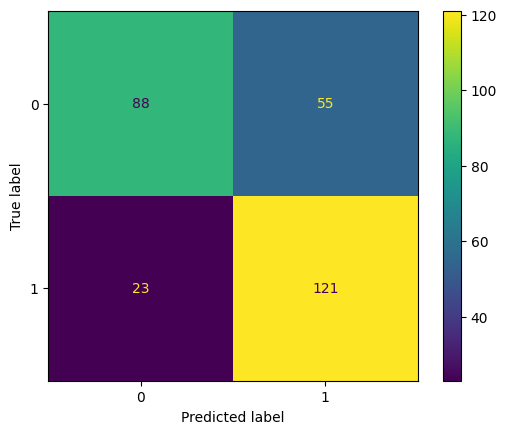

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_probs > 0.5).astype(int)

# Flatten array
y_pred = y_pred.flatten()

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [ ]:
#Model 2 — Bidirectional LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2
)

# =========================
# EVALUATE
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.5098 - loss: 0.6923 - val_accuracy: 0.4682 - val_loss: 0.6930
Epoch 2/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.6532 - loss: 0.6586 - val_accuracy: 0.6479 - val_loss: 0.6401
Epoch 3/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.8144 - loss: 0.4622 - val_accuracy: 0.6667 - val_loss: 0.7501
Epoch 4/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 212ms/step - accuracy: 0.9503 - loss: 0.1575 - val_accuracy: 0.6629 - val_loss: 1.0108
Epoch 5/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.9681 - loss: 0.0766 - val_accuracy: 0.6891 - val_loss: 0.9239
Epoch 6/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.9859 - loss: 0.0428 - val_accuracy: 0.7191 - val_loss: 1.0814
Epoch 7/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.9963 - loss: 0.0119 - val_accuracy: 0.6667 - val_loss: 1.3921
Epoch 8/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9981 - loss: 0.0103 - val_accuracy: 0.6891 -

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


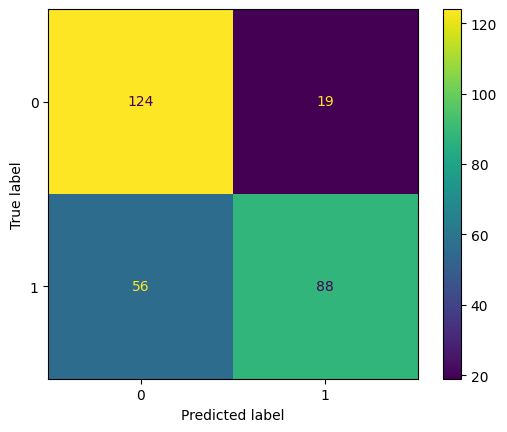

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_probs > 0.5).astype(int)

# Flatten array
y_pred = y_pred.flatten()

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [ ]:
#Model 3 — CNN for Text Classification

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),

    Conv1D(128, 5, activation='relu'),

    GlobalMaxPooling1D(),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2
)

# =========================
# EVALUATE
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.4986 - loss: 0.6950 - val_accuracy: 0.6404 - val_loss: 0.6882
Epoch 2/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6710 - loss: 0.6630 - val_accuracy: 0.5094 - val_loss: 0.6786
Epoch 3/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7751 - loss: 0.5806 - val_accuracy: 0.6180 - val_loss: 0.6341
Epoch 4/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.9063 - loss: 0.3981 - val_accuracy: 0.7603 - val_loss: 0.5195
Epoch 5/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9625 - loss: 0.1874 - val_accuracy: 0.7041 - val_loss: 0.5474
Epoch 6/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9888 - loss: 0.0839 - val_accuracy: 0.7753 - val_loss: 0.4936
Epoch 7/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.9944 - loss: 0.0387 - val_accuracy: 0.7603 - val_loss: 0.5179
Epoch 8/8
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9972 - loss: 0.0212 - val_accuracy: 0.7865 - val_loss:

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


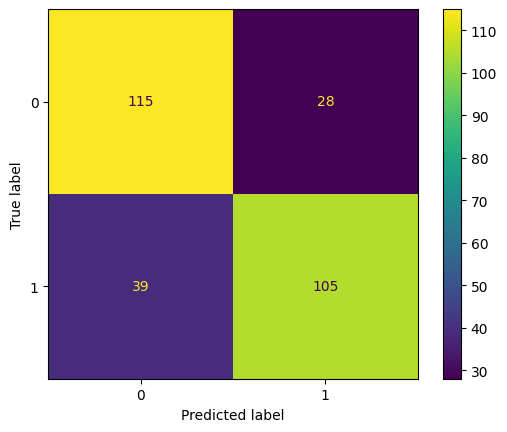

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_probs > 0.5).astype(int)

# Flatten array
y_pred = y_pred.flatten()

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [ ]:
#Model 3 — CNN for Text Classification - Improved Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),

    SpatialDropout1D(0.2),

    Conv1D(64, 5, activation='relu'),

    GlobalMaxPooling1D(),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

# =========================
# EVALUATE
# =========================
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.5145 - loss: 0.6925 - val_accuracy: 0.5506 - val_loss: 0.6910
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.5417 - loss: 0.6847 - val_accuracy: 0.5768 - val_loss: 0.6874
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6514 - loss: 0.6705 - val_accuracy: 0.5431 - val_loss: 0.6812
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7038 - loss: 0.6369 - val_accuracy: 0.6180 - val_loss: 0.6622
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7807 - loss: 0.5654 - val_accuracy: 0.6742 - val_loss: 0.6191
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8604 - loss: 0.4382 - val_accuracy: 0.7491 - val_loss: 0.5418
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9110 - loss: 0.3046 - val_accuracy: 0.7416 - val_loss: 0.5214
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9325 - loss: 0.2026 - val_accuracy: 0.7566 - val_loss: 0.

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


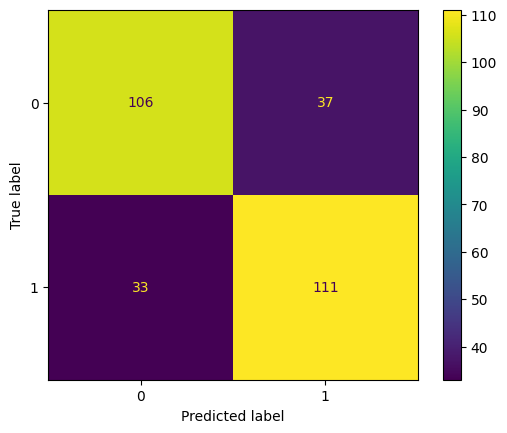

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_probs > 0.5).astype(int)

# Flatten array
y_pred = y_pred.flatten()

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()